# Phân tích dữ liệu retailrocket

Nguyễn Ngọc Hoàng Nam — B23DCCN585 | ASG 06

Các cell nhỏ được sắp theo thứ tự phụ thuộc. Huấn luyện đầy đủ mặc định tắt; số liệu chạy thử không phải kết quả test chính thức.

In [1]:
from pathlib import Path
import sys, json, os
ROOT=Path.cwd().resolve()
if ROOT.name=="notebooks": ROOT=ROOT.parent
assert (ROOT/"src").is_dir()
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from src.paths import DATA
from src.io import read_json
import numpy as np
import pandas as pd
from IPython.display import display, Image
print("Project:", ROOT)
print("Data:", DATA)


Project: E:\PTHTTM\ASG_06
Data: E:\PTHTTM\ASG_06_data


## 1. Nguồn và kiểm tra dữ liệu

In [2]:
from src.data import load_data,split_ids,make_batch
data=load_data('retailrocket')
meta=data['metadata']
display(meta)

{'dataset': 'retailrocket',
 'features': ['view',
  'addtocart',
  'transaction',
  'log_gap_seconds',
  'same_item_as_previous',
  'log_session_position',
  'hour_sin',
  'hour_cos',
  'weekday_sin',
  'weekday_cos'],
 'input_dim': 10,
 'sequence_length': 20,
 'cutoffs_utc': ['2015-08-08T00:00:00+00:00', '2015-08-29T00:00:00+00:00'],
 'split_sizes': {'train': 747842, 'val': 122917, 'test': 118192},
 'scaler_mean': [0.9684806831403948,
  0.024763839312126532,
  0.006755477547478652,
  1.5610780876545785,
  0.10254008322322362,
  0.5320501371533713,
  -0.18216785729259052,
  0.3024428291977769,
  0.08615441665781866,
  0.011987753303315899],
 'scaler_scale': [0.17471648326596886,
  0.15540460602750308,
  0.08191361956500105,
  2.228577283338054,
  0.3033572391624871,
  0.8868430370093274,
  0.7251336280867868,
  0.591205910396801,
  0.6880319217657125,
  0.720448314685107],
 'raw_sha256': 'b605e916a9379585d4a0a3f3c76abe7e5be4ed178b73d969e89061a2340ae191',
 'raw_rows': 2756101,
 'exact_d

## 2. Tập chia theo thời gian

In [3]:
rows=[]
for split in ['train','val','test']:
    ids=split_ids(data,split)
    rows.append([split,len(ids),pd.to_datetime(data['times'][ids].min(),unit='s'),pd.to_datetime(data['times'][ids].max(),unit='s')])
display(pd.DataFrame(rows,columns=['split','samples','first target','last target']))

,split,samples,first target,last target
0,train,747842,2015-05-03 03:00:26,2015-08-07 23:59:59
1,val,122917,2015-08-08 00:00:43,2015-08-28 23:59:23
2,test,118192,2015-08-29 00:00:55,2015-09-18 02:59:47


## 3. Cấu trúc batch và phần đệm

In [4]:
ids=split_ids(data,'train')[:8]
x,lengths,y=make_batch(data,ids)
print('X:',x.shape,'lengths:',lengths,'targets:',y)
display(pd.DataFrame(x[0,:lengths[0]],columns=meta['features']))

X: (8, 20, 10) lengths: [1 2 3 4 5 6 7 1] targets: [0 0 0 0 0 0 0 0]


,view,addtocart,transaction,log_gap_seconds,same_item_as_previous,log_session_position,hour_sin,hour_cos,weekday_sin,weekday_cos
0,0.180403,-0.159351,-0.082471,-0.700482,-0.338018,-0.599937,-1.126773,-0.577976,-0.755834,-1.267206


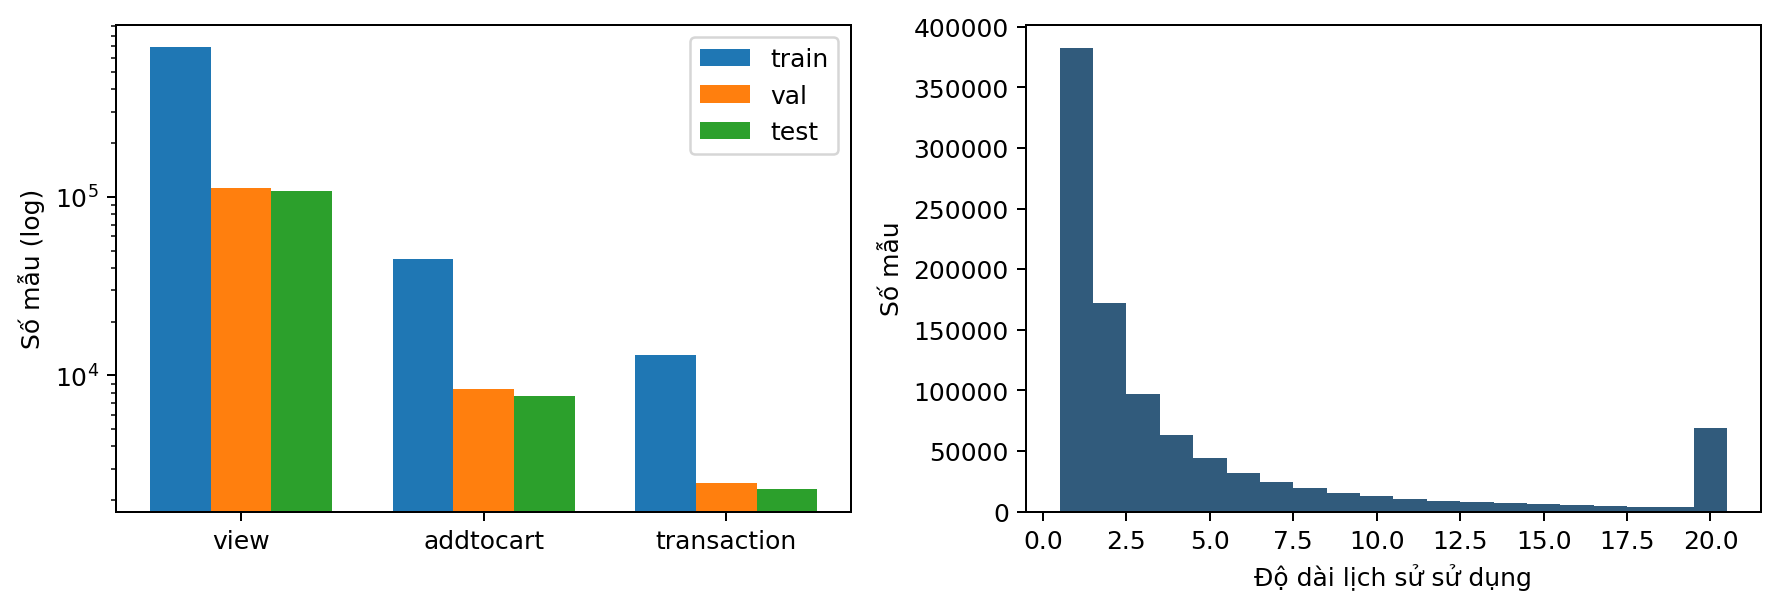

In [5]:
display(Image(filename=str(ROOT/'figures/retail_distribution.png')))

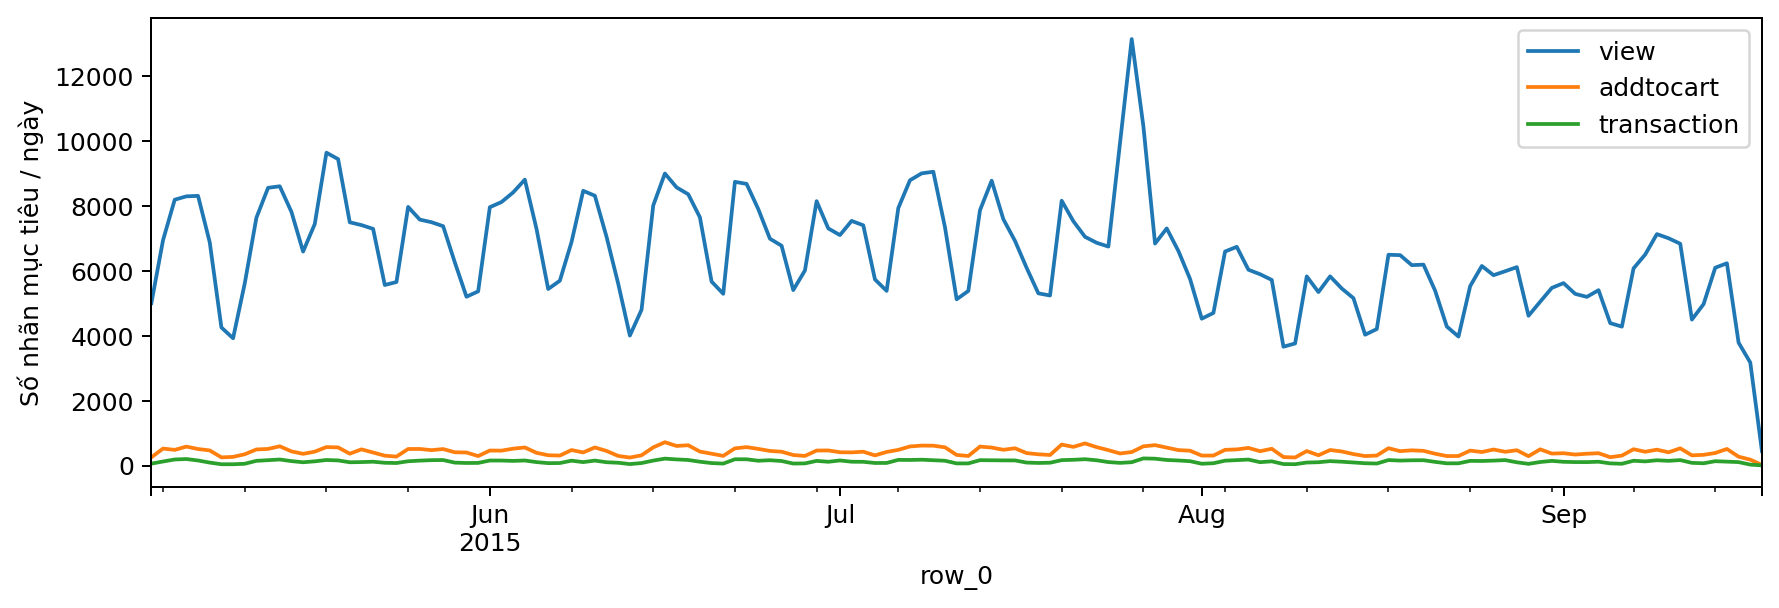

In [6]:
display(Image(filename=str(ROOT/'figures/retail_daily.png')))

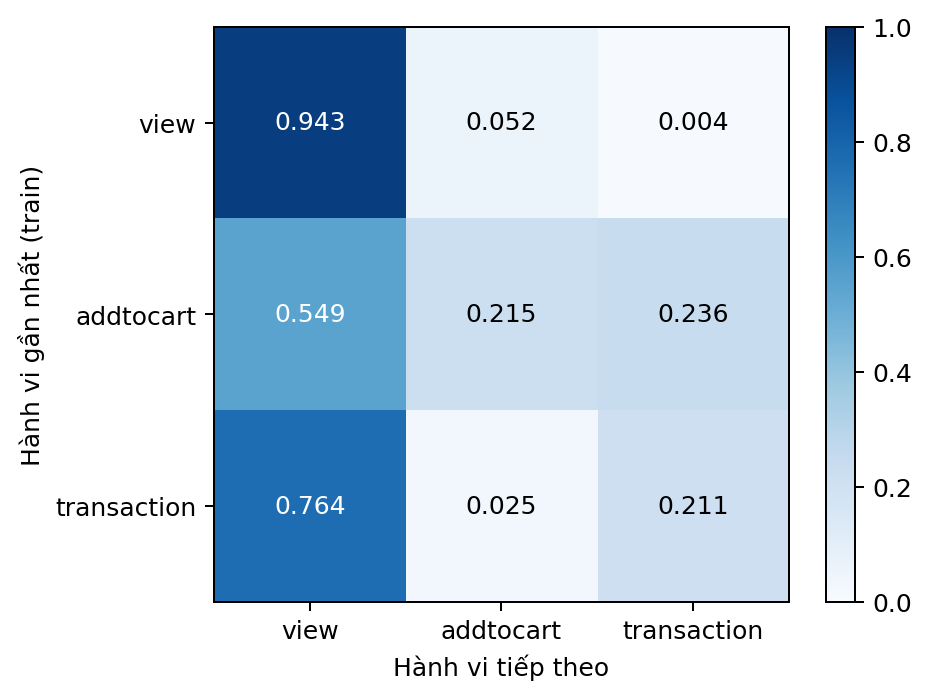

In [7]:
display(Image(filename=str(ROOT/'figures/retail_transition.png')))

## 4. Giới hạn
Chỉ dự đoán loại hành vi tiếp theo khi phiên còn sự kiện. Khách trở lại có thể xuất hiện ở nhiều giai đoạn. Sự kiện trùng thời điểm gây thứ tự không xác định bị loại và được thống kê.